# Week 8 Assignment — Agentic AI Pipeline
## Single Agent System with Tools



## Problem Statement

Build a **Single-Agent Smart Assistant** that:
- Understands the user's query
- Routes the task based on intent (conditional routing)
- Calls the right tool when one is needed
- Returns a structured JSON output in every case

**Required routing behaviour**
| Query type | Handler |
|---|---|
| Math expressions | Calculator Tool |
| Keyword extraction requests | Keyword Extractor Tool |
| Anything else | General Response |

**Implementation requirements:** agent logic, conditional routing, tool integration, basic error handling.
**Output contract:** every call to the agent returns `{"type": ..., "result": ...}`.

## 1. Tool — Calculator

Rather than passing the raw string straight to `eval`, the expression is first checked against a
whitelist of characters (digits, decimal points, and `+ - * / ( ) %` operators). This prevents
arbitrary code from being executed through the tool and keeps `eval` sandboxed with
`{"__builtins__": {}}`. Division-by-zero and malformed expressions are caught and reported with a
specific, useful message rather than a generic failure.

In [1]:
import re

ALLOWED_EXPRESSION_PATTERN = re.compile(r"^[0-9\.\+\-\*\/\(\)\s%]+$")


def calculator(expression: str) -> dict:
    """
    Safely evaluate a math expression.

    Returns a dict: {"success": bool, "value": float | None, "error": str | None}
    """
    expression = expression.strip()

    if not expression:
        return {"success": False, "value": None, "error": "Empty expression."}

    if not ALLOWED_EXPRESSION_PATTERN.match(expression):
        return {"success": False, "value": None, "error": "Expression contains unsupported characters."}

    try:
        value = eval(expression, {"__builtins__": {}}, {})
        return {"success": True, "value": float(value), "error": None}
    except ZeroDivisionError:
        return {"success": False, "value": None, "error": "Division by zero."}
    except SyntaxError:
        return {"success": False, "value": None, "error": "Malformed expression."}
    except Exception as e:
        return {"success": False, "value": None, "error": f"Calculation failed: {e}"}

## 2. Tool — Keyword Extractor

A frequency-ranked extractor: it strips punctuation, drops common stopwords, then ranks the
remaining words by how often they appear (ties broken by first appearance) and returns the top 5.
This is more informative than a plain length filter because it surfaces words that actually matter
to the sentence rather than just "long" words.

In [2]:
from collections import Counter
import string

STOPWORDS = {
    "the", "a", "an", "is", "are", "was", "were", "of", "for", "in", "on", "to",
    "and", "or", "this", "that", "with", "from", "by", "at", "as", "it", "be",
    "extract", "keywords", "keyword", "text", "please"
}


def extract_keywords(text: str, top_n: int = 5) -> list:
    """Extract the top_n most relevant keywords from a piece of text."""
    if not text or not text.strip():
        return []

    cleaned = text.lower().translate(str.maketrans("", "", string.punctuation))
    words = [w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2]

    if not words:
        return []

    ranked = Counter(words).most_common(top_n)
    return [word for word, _count in ranked]

## 3. Agent — Conditional Routing + Error Handling

The router inspects the query, decides which tool (if any) is needed, and always returns the same
`{"type": ..., "result": ...}` shape. A `jsonschema` check on the way out guarantees every response
matches that contract before it leaves the function — catching a malformed response is treated the
same as any other tool failure.

In [3]:
from jsonschema import validate, ValidationError

AGENT_OUTPUT_SCHEMA = {
    "type": "object",
    "properties": {
        "type": {"type": "string", "enum": ["calculation", "keywords", "general", "error"]},
        "result": {}
    },
    "required": ["type", "result"]
}


def agent(query: str) -> dict:
    """Route a query to the right tool and return a structured JSON response."""
    if not isinstance(query, str) or not query.strip():
        response = {"type": "error", "result": "Query must be a non-empty string."}
        return response

    query_lower = query.lower()

    try:
        if "calculate" in query_lower:
            expression = query_lower.split("calculate", 1)[1].strip()
            outcome = calculator(expression)
            if outcome["success"]:
                response = {"type": "calculation", "result": outcome["value"]}
            else:
                response = {"type": "error", "result": outcome["error"]}

        elif "keyword" in query_lower:
            # Strip the instruction phrase, keep the actual text to analyze
            text = re.sub(r"extract\s+keywords?\s+from", "", query, flags=re.IGNORECASE).strip()
            keywords = extract_keywords(text)
            if keywords:
                response = {"type": "keywords", "result": keywords}
            else:
                response = {"type": "error", "result": "No meaningful keywords found in the text."}

        else:
            response = {
                "type": "general",
                "result": "This is a general query — no specialised tool was required."
            }

    except Exception as e:
        response = {"type": "error", "result": f"Unhandled agent error: {e}"}

    try:
        validate(instance=response, schema=AGENT_OUTPUT_SCHEMA)
    except ValidationError:
        response = {"type": "error", "result": "Agent produced a malformed response."}

    return response

## 4. Pipeline Diagram

Shown as an actual branching flow (query → router → one of three tools, all converging on the same
JSON output shape) rather than a single straight line, since the whole point of conditional routing
is that the path *forks* depending on intent.

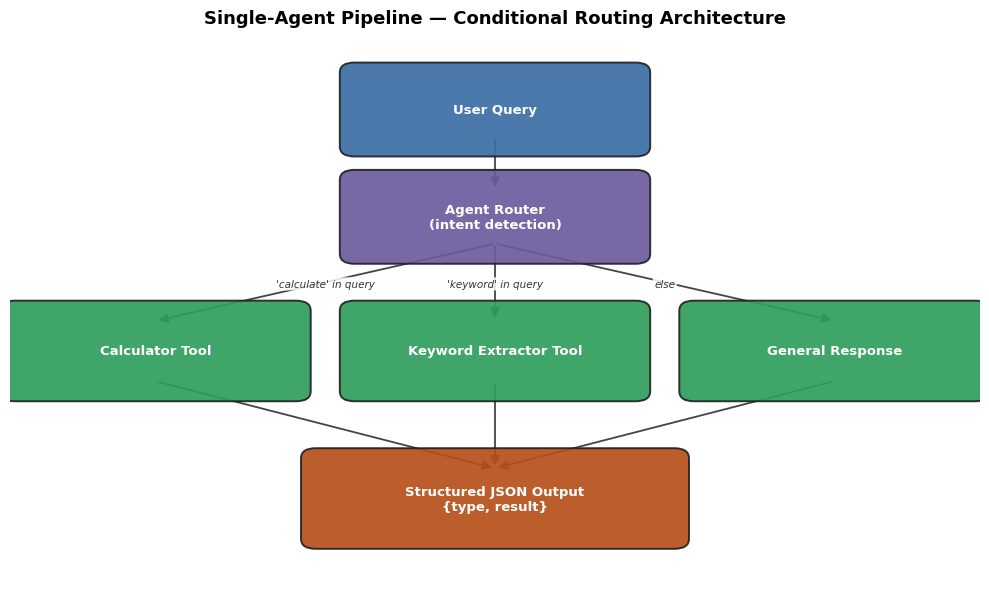

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

node_style = dict(boxstyle="round,pad=0.3,rounding_size=0.15", linewidth=1.4)

nodes = {
    "query":     {"pos": (5, 7),   "size": (2.6, 0.8), "label": "User Query",        "color": "#3B6EA5"},
    "router":    {"pos": (5, 5.4), "size": (2.6, 0.8), "label": "Agent Router\n(intent detection)", "color": "#6C5B9E"},
    "calc":      {"pos": (1.5, 3.4), "size": (2.6, 0.9), "label": "Calculator Tool",  "color": "#2F9E5B"},
    "keyword":   {"pos": (5, 3.4),   "size": (2.6, 0.9), "label": "Keyword Extractor Tool", "color": "#2F9E5B"},
    "general":   {"pos": (8.5, 3.4), "size": (2.6, 0.9), "label": "General Response",  "color": "#2F9E5B"},
    "output":    {"pos": (5, 1.2), "size": (3.4, 0.9), "label": "Structured JSON Output\n{type, result}", "color": "#B5501A"},
}

for key, n in nodes.items():
    x, y = n["pos"]
    w, h = n["size"]
    box = FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                          facecolor=n["color"], edgecolor="#222222",
                          alpha=0.92, zorder=2, **node_style)
    ax.add_patch(box)
    ax.text(x, y, n["label"], ha="center", va="center",
             fontsize=9.5, fontweight="bold", color="white", zorder=3)

edges = [
    ("query", "router"),
    ("router", "calc"),
    ("router", "keyword"),
    ("router", "general"),
    ("calc", "output"),
    ("keyword", "output"),
    ("general", "output"),
]

edge_labels = {
    ("router", "calc"): "'calculate' in query",
    ("router", "keyword"): "'keyword' in query",
    ("router", "general"): "else",
}

for start, end in edges:
    x1, y1 = nodes[start]["pos"]
    x2, y2 = nodes[end]["pos"]
    h1 = nodes[start]["size"][1] / 2
    h2 = nodes[end]["size"][1] / 2
    arrow = FancyArrowPatch((x1, y1 - h1), (x2, y2 + h2),
                              arrowstyle="-|>", mutation_scale=14,
                              linewidth=1.3, color="#444444", zorder=1,
                              connectionstyle="arc3,rad=0.0")
    ax.add_patch(arrow)
    if (start, end) in edge_labels:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my, edge_labels[(start, end)], ha="center", va="center",
                 fontsize=7.5, style="italic", color="#333333",
                 bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85))

ax.set_title("Single-Agent Pipeline — Conditional Routing Architecture",
             fontsize=13, fontweight="bold", pad=14)

plt.tight_layout()
plt.savefig("agent_pipeline_diagram.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Test Cases

Covers all three routing branches plus edge cases (division by zero, malformed expression, empty
keyword text) to demonstrate the error handling paths, not just the happy path.

In [5]:
test_queries = [
    "Calculate 15 * 3 - 7",
    "Calculate 10 / 0",
    "Calculate 2 +",
    "Extract keywords from The quick brown fox jumps over the lazy dog multiple times",
    "keywords please: Machine learning models require large datasets to generalise well",
    "What is the capital of France?",
]

for q in test_queries:
    print("Query:   ", q)
    print("Response:", agent(q))
    print("-" * 70)

Query:    Calculate 15 * 3 - 7
Response: {'type': 'calculation', 'result': 38.0}
----------------------------------------------------------------------
Query:    Calculate 10 / 0
Response: {'type': 'error', 'result': 'Division by zero.'}
----------------------------------------------------------------------
Query:    Calculate 2 +
Response: {'type': 'error', 'result': 'Malformed expression.'}
----------------------------------------------------------------------
Query:    Extract keywords from The quick brown fox jumps over the lazy dog multiple times
Response: {'type': 'keywords', 'result': ['quick', 'brown', 'fox', 'jumps', 'over']}
----------------------------------------------------------------------
Query:    keywords please: Machine learning models require large datasets to generalise well
Response: {'type': 'keywords', 'result': ['machine', 'learning', 'models', 'require', 'large']}
----------------------------------------------------------------------
Query:    What is the capi

## 6. Bonus — Result Summary

A quick tally of how the test batch broke down by response type, useful as a lightweight stand-in
for the task-completion-rate metric discussed in the quiz.

In [6]:
import pandas as pd

records = [{"query": q, **agent(q)} for q in test_queries]
results_df = pd.DataFrame(records)
results_df

,query,type,result
0,Calculate 15 * 3 - 7,calculation,38.0
1,Calculate 10 / 0,error,Division by zero.
2,Calculate 2 +,error,Malformed expression.
3,Extract keywords from The quick brown fox jump...,keywords,"[quick, brown, fox, jumps, over]"
4,keywords please: Machine learning models requi...,keywords,"[machine, learning, models, require, large]"
5,What is the capital of France?,general,This is a general query — no specialised tool ...


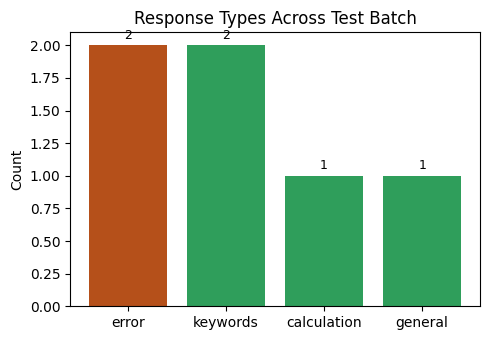

In [7]:
type_counts = results_df["type"].value_counts()

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = {"calculation": "#2F9E5B", "keywords": "#2F9E5B", "general": "#2F9E5B", "error": "#B5501A"}
bar_colors = [colors.get(t, "#888888") for t in type_counts.index]
ax.bar(type_counts.index, type_counts.values, color=bar_colors)
ax.set_ylabel("Count")
ax.set_title("Response Types Across Test Batch")
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 0.05, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("response_type_summary.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Interactive Mode

Run this cell in a live Jupyter session to query the agent directly. In a non-interactive/batch
execution (like automated grading or `nbconvert --execute` without a terminal), it exits gracefully
instead of crashing.

In [8]:
while True:
    try:
        user_input = input("Enter query (type \'exit\' to stop): ")
    except Exception:
        print("No interactive input detected — skipping interactive mode.")
        break
    if user_input.strip().lower() == "exit":
        break
    print("Response:", agent(user_input))

Enter query (type 'exit' to stop): add 4 and 5
Response: {'type': 'general', 'result': 'This is a general query — no specialised tool was required.'}
Enter query (type 'exit' to stop): 6+1
Response: {'type': 'general', 'result': 'This is a general query — no specialised tool was required.'}
Enter query (type 'exit' to stop): exit


## Final Insights — Agentic AI Pipeline

### What is an AI Agent?
An AI agent is a system that interprets a user's intent, decides — rather than being told — which
tool (if any) is needed, invokes that tool, and returns a response. That decision step is what
separates an agent from a plain function call.

### Routing Logic Built
- **"calculate"** in the query → Calculator Tool (safe, whitelisted expression evaluation)
- **"keyword"** in the query → Keyword Extractor Tool (stopword-filtered, frequency-ranked)
- **Anything else** → General Response

### Key Concepts Demonstrated
- **Conditional routing** — the agent's path branches based on query content instead of following
  one fixed sequence every time.
- **Structured JSON output** — every branch, including failures, returns the same
  `{"type", "result"}` shape, validated against a JSON schema before being returned.
- **Layered error handling** — each tool returns a `success`/`error` outcome internally; the agent
  wraps everything in a try/except as a second line of defence; and the final schema check is a
  third. A bad query (division by zero, malformed expression, empty text) never crashes the pipeline.

